# Task 1 — Binary Classification of OT-VA Site of Origin (LVOT vs RVOT)

Classify the site of origin of idiopathic outflow tract ventricular arrhythmias
into **LVOT** (left) vs **RVOT** (right) using 12-lead ECG and clinical data.

**Models compared:**
1. **Hybrid Score** (Penela et al. 2023) — clinical baseline rule
2. **Random Forest** (Bocanegra-Pérez et al. 2024 — Model B-style) — handcrafted features
3. **CNN** (Saglietto et al. 2024-inspired) — end-to-end deep learning on raw ECG
4. **Late-fusion ensemble** — RF + CNN combined

### 1.1. Imports

In [1]:
import numpy as np
from scipy import signal
from sklearn.preprocessing import normalize
from scipy.io import loadmat
import pickle
import pandas as pd
import matplotlib.pyplot as plt

### 1.2. Helper functions for `.mat` datasets

These functions (provided by the professor) parse the Matlab `.mat` files and
return numpy arrays. Each `.mat` contains pre-segmented QRS complexes that we
resample to 128 samples per lead.


In [2]:
def _handle_sublocation(dSim: dict,
                        data_key: str,
                        path: str,
                        X: np.ndarray,
                        y: np.ndarray) -> (np.ndarray, np.ndarray, np.ndarray):
    """
    Handle sublocation classification and remove invalid samples.
    """

    mapping = {
        'LCC': 0, 'RCC': 1, 'COMMISSURE': 2, 'LVOT Subvalvular': 3,
        'LVOT Summit': 4, 'RVOT Septum': 5, 'RFW': 6 #RVOT Free Wall
    }

    #Dataset-specific exclusions
    if path == 'data/QRS_CARTO2.mat':
        invalid_labels = ['RV', []]
    elif path == 'data/QRS_Database2.mat':
        invalid_labels = ['-', 'RVOTOther']
    else:
        invalid_labels = []

    raw_labels = dSim[data_key]["Sublocation"]

    y_sub = []
    valid_indices = []
    unique_labels = []

    for i, label in enumerate(raw_labels[0]):

        try:
            if label[0] in invalid_labels:
                continue

            else:
                if label[0] == 'LCCRCC' or label[0] == 'LCC-RCC':
                    label = 'COMMISSURE'

                elif label[0] == 'Posteroseptal' or label[0] == 'Anteroseptal':
                    label = 'RVOT Septum'

                elif label[0] == "AMC":
                    label = 'LVOT Subvalvular'

                elif label[0] == "Summit":
                    label = 'LVOT Summit'

                else:
                    label = label[0]

                if label in mapping:
                    y_sub.append(mapping[label])
                    valid_indices.append(i)
                    if label not in unique_labels:
                        unique_labels.append(label)
                else:
                    print(f"Warning: unknown sublocation '{label}' at index {i}")

        except:
            print(f"Warning: invalid label format at index {i}: {label}")
            continue


    print(f"Unique sublocation labels found: {unique_labels}")
    #Filter dataset
    X = X[valid_indices]
    y = y[valid_indices]
    y_sub = np.array(y_sub)

    return X, y, y_sub

In [3]:
def _build_binary_target(dSim: dict,
                         data_key: str) -> np.ndarray:
    """
    Build LV (0) vs RV (1) classification target.
    """

    mapping = {"LV": 0, "RV": 1}
    #Handle typo inconsistency in datasets
    key_name = "LeftRight" if "LeftRight" in dSim[data_key].dtype.names else "LeftRigth"

    raw_labels = dSim[data_key][key_name]
    y = np.zeros(len(raw_labels[0]))

    for i, label in enumerate(raw_labels[0]):
        y[i] = mapping[label[0]]

    return y

In [4]:
def _load_mat_dataset(path, sample_size, data_key,
                      lead_names, sublocation):
    """
    Internal function to load .mat ECG datasets.
    """
    #dSim has the data at data_key (e.g., QRS_CARTO), and then for each lead, we have a (1, n_patients) list, where each entry is a (n_samples,) array with the ECG signal for that patient and lead.
    dSim = loadmat(path)

    #Number of patients
    n_patients = dSim[data_key][lead_names[0]].shape[1]
    print(f"Number of patients: {n_patients}")

    #Allocate matrix: (patients × (leads * samples))
    X = np.zeros((n_patients, len(lead_names) * sample_size))

    #Build feature matrix
    for iLead, lead in enumerate(lead_names):
        lead_data = dSim[data_key][lead]

        for i in range(n_patients):
            patient_signal = lead_data[0, i]
            signal_1d = np.asarray(patient_signal).squeeze() #Convert to 1D array

            #Safety check
            if signal_1d.ndim != 1:
                raise ValueError(
                    f"Invalid ECG shape at patient {i}, lead {lead}: {signal_1d.shape}"
                )
            #Resample signal to fixed length
            resampled = signal.resample(signal_1d, sample_size).flatten()

            # Place in correct position
            start = iLead * sample_size
            end = (iLead + 1) * sample_size
            X[i, start:end] = resampled

    #Normalize (important for ML stability)
    X = normalize(X, norm="l1") #every row (patient) is divided by the sum of the values. This makes comparable the signals measured at different voltages
    #l1 because it preserves the relative form of the signal without altering the sign

    #Build targets
    y = _build_binary_target(dSim, data_key)

    if sublocation:
        X, y, y_sub = _handle_sublocation(dSim, data_key, path, X, y)

    return {
        "data": X,
        "target": y
    }


In [5]:
def load_dataset(path: str,
                 sample_size: int,
                 data_key: str,
                 lead_names: list = None,
                 sublocation: bool = False,
                 shuffle: bool = True,
                 random_state: int = None):
    """
    Load ECG dataset and return (X, y).

    This function:
    1. Loads raw ECG data
    2. Resamples each lead
    3. Flattens all 12 leads into a single vector per patient
    4. Normalizes the data
    5. Builds target labels

    Parameters:
    path : str --> Path to .mat file
    sample_size : int --> Number of samples per lead after resampling
    data_key : str --> Key inside .mat file (e.g. 'QRS')
    lead_names : list --> ECG leads to use (default: standard 12-lead)
    sublocation : bool --> If True, also compute sublocation labels
    shuffle : bool --> Whether to shuffle dataset
    random_state : int or None --> Seed for reproducibility

    Returns:
    X : np.ndarray --> Shape (n_samples, n_leads * sample_size)
    y : np.ndarray --> Binary labels (LV=0, RV=1)
    """
    if lead_names is None:
        lead_names = ["I","II","III","aVR","aVL","aVF",
                      "V1","V2","V3","V4","V5","V6"]

    print(f"Loading dataset from: {path}")

    # Load and process raw data
    DB_dict = _load_mat_dataset(path, sample_size, data_key,
                                lead_names, sublocation)

    X = DB_dict["data"]
    y = DB_dict["target"]

    # Shuffle if needed
    if shuffle:
        rng = np.random.default_rng(random_state)
        indices = rng.permutation(len(X))
        X = X[indices]
        y = y[indices]

    return X, y

### 1.3. Load all three datasets

In [6]:
# Update these paths to your local data folder
DS43_PATH = r'./data/QRS_CARTO2.mat'  # Hospital Clínic
DS334_PATH = r'./data/QRS_Database2.mat' # Open-source
TEKNON_PATH = r'./data/full_data_corrected_2024.pkl'

SAMPLE_SIZE = 128   # samples per lead — fixed for the entire pipeline (better than 10 for deep learning)

# Load DS-43 (Hospital Clínic, 43 real patients)
X_Clinic, y_Clinic = load_dataset(
    DS43_PATH, sample_size=SAMPLE_SIZE,
    data_key="QRS_CARTO",
    lead_names=["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"],
    sublocation=False, shuffle=False
)
print(f"DS-43 (Clínic): X={X_Clinic.shape}, balance: "
      f"LVOT={int((y_Clinic==0).sum())}, RVOT={int((y_Clinic==1).sum())}")

# Load DS-334 (open-source database, Zheng et al. 2021)
X_China, y_China = load_dataset(
    DS334_PATH, sample_size=SAMPLE_SIZE,
    data_key="QRS",
    lead_names=["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"],
    sublocation=False, shuffle=False
)
print(f"DS-334 (Open):  X={X_China.shape}, balance: "
      f"LVOT={int((y_China==0).sum())}, RVOT={int((y_China==1).sum())}")


Loading dataset from: ./data/QRS_CARTO2.mat
Number of patients: 43
DS-43 (Clínic): X=(43, 1536), balance: LVOT=26, RVOT=17
Loading dataset from: ./data/QRS_Database2.mat
Number of patients: 333
DS-334 (Open):  X=(333, 1536), balance: LVOT=77, RVOT=256


In [7]:
# Load Teknon (DS-181): 4-beat ECG signals + clinical variables
import pickle
with open(TEKNON_PATH, "rb") as f:
    teknon = pickle.load(f)

# Separate clinical metadata from ECG signal arrays
ECG_KEYS = ["I","II","III","AVR","AVL","AVF","V1","V2","V3","V4","V5","V6"]
clinical_df = pd.DataFrame({k: v for k, v in teknon.items() if k not in ECG_KEYS})
print(f"Teknon: {len(clinical_df)} patients, {clinical_df.shape[1]} clinical variables")
print(f"\nClinical columns: {list(clinical_df.columns)}")


Teknon: 181 patients, 16 clinical variables

Clinical columns: ['Sex', 'HTA', 'Age', 'PVC_transition', 'SOO_chamber', 'Height', 'Weight', 'BMI', 'DM', 'DLP', 'Smoker', 'COPD', 'Sleep_apnea', 'CLINICAL_SCORE', 'SOO', 'OTorigin']


## 2. SOO Label Standardization

Teknon's `SOO` field is free-text written by clinicians (Spanish, with typos and
inconsistent casing). We map every raw string to one of **7 standard anatomical
classes** (defined in the project specification, slide 12):

| Class | Anatomical region | Side |
|---|---|---|
| LCC | Left Coronary Cusp | LVOT |
| RCC | Right Coronary Cusp | LVOT |
| COMMISSURE | LCC-RCC inter-sinus | LVOT |
| LVOT Subvalvular | Subvalvular LVOT (AMC) | LVOT |
| LVOT Summit | LV Summit | LVOT |
| RVOT Septum | RVOT septal wall | RVOT |
| RFW | RVOT Free Wall | RVOT |

Two additional categories:
- **EXCLUDE**: origin outside the outflow tract (papillary muscles, mitral/tricuspid
  annuli, fascicular system) → not relevant for OT-VA classification → discarded.
- **UNCERTAIN**: ambiguous strings or `NaN` → discarded for safety.

For Task 1, we reduce the 7 classes to **2 binary classes** (LVOT vs RVOT).


In [8]:
# Free-text --> standard class mapping 
SOO_MAPPING = {
    # LCC (Left Coronary Cusp)
    "LCC": "LCC", "Left coronary cusp": "LCC",
    "Left coronary cusp, desde el ventriculo izquierdo": "LCC",
    "Cúspide izquierda": "LCC", "Seno de Valsalva izdo.": "LCC",
    "LVOT Seno de Valsalva izdo.": "LCC", "LVOT Seno de Valsava izdo.": "LCC",
    # RCC (Right Coronary Cusp)
    "RCC": "RCC", "Seno de Valsalva dcho.": "RCC",
    # COMMISSURE (LCC-RCC junction)
    "Intersenos dcho.-izdo.": "COMMISSURE", "LVOT intersenos dcho.-izdo.": "COMMISSURE",
    "Intersenos": "COMMISSURE", "Intersenos (LV)": "COMMISSURE", "Intersinus": "COMMISSURE",
    # LVOT Subvalvular
    "Unión mitroaórtica": "LVOT Subvalvular", "Septo basal subaótico": "LVOT Subvalvular",
    "Postero Septal Subvalvular": "LVOT Subvalvular",
    "Septo posterior, immediatamente subvalvular": "LVOT Subvalvular",
    "LVOT anterolateral": "LVOT Subvalvular",
    # LVOT Summit
    "Summit": "LVOT Summit", "LV summit": "LVOT Summit",
    "LV summit EPI (SC)": "LVOT Summit", "CS distal (summit)": "LVOT Summit",
    "subvalvular aortico (summit)": "LVOT Summit",
    # RVOT Septum
    "RVOT septal": "RVOT Septum", "RVOT medioseptal": "RVOT Septum",
    "RVOT anteroseptal": "RVOT Septum", "RVOT posteroseptal": "RVOT Septum",
    "rvot postero septal": "RVOT Septum", "rvot septo posterior": "RVOT Septum",
    "rvot sèeto posterior": "RVOT Septum", "rvot septal anterior": "RVOT Septum",
    "RVOT septal subvalvular": "RVOT Septum", "RVOT subvalvular septal": "RVOT Septum",
    "RVOT anteroseptal subvalvular": "RVOT Septum",
    "RVOT posterior": "RVOT Septum", "RVOT anterior": "RVOT Septum",
    "Septo anterior": "RVOT Septum", "septo": "RVOT Septum",
    "RVOT": "RVOT Septum", "Infundíbulo": "RVOT Septum",
    "Infudibulo": "RVOT Septum", "Infundibulo": "RVOT Septum",
    # RFW (RVOT Free Wall)
    "Pared libre anterior": "RFW", "pared libre anterior": "RFW",
    "RVOT anterolateral": "RFW", "RVOT posterolateral": "RFW",
    "rvot pared libre": "RFW", "rvot - pared libre": "RFW",
    "Pared libre anterolateral": "RFW", "RVOT lateral": "RFW",
    "RVOT lateral + septal": "RFW",
    # EXCLUDE (non-OT origins — papillary, annuli, fascicular)
    "M. papilar posteromedial": "EXCLUDE", "M. papilar anterolateral": "EXCLUDE",
    "Papilar inferolateral": "EXCLUDE", "Papilar anterolateral": "EXCLUDE",
    "Papilar inferior": "EXCLUDE", "papilar lateral": "EXCLUDE",
    "Musculo papilar infero-medial": "EXCLUDE",
    "Anillo mitral posterior": "EXCLUDE",
    "Anillo mitral inferolateral + Unión M-A": "EXCLUDE",
    "Anillo mitral anteroseptal": "EXCLUDE",
    "Anillo mitral anterolateral": "EXCLUDE", "anillo lat": "EXCLUDE",
    "Anillo tricuspídeo inferior/inferoseptal": "EXCLUDE",
    "Anillo tricuspídeo lateral": "EXCLUDE",
    "Anillo tricuspídeo anterior": "EXCLUDE",
    "Anillo tricuspídeo septal": "EXCLUDE",
    "Fascicular posterior": "EXCLUDE", "Fascicular anterior": "EXCLUDE",
    "Fascículo anterior": "EXCLUDE", "fasciculo anterior LV": "EXCLUDE",
    "LV inferobasal": "EXCLUDE", "LV inferolateral basal": "EXCLUDE",
    "LV inferoseptal medio": "EXCLUDE", "LV perihisiana": "EXCLUDE",
    "VI anteroseptal basal": "EXCLUDE", "VI anteroseptal medio": "EXCLUDE",
    "VI inferoseptal basal": "EXCLUDE", "Inferoseptal basal": "EXCLUDE",
    "Septo basal izquierdo": "EXCLUDE", "Banda moderadora": "EXCLUDE",
    "Ostium del SC (crux cordis)": "EXCLUDE", "Crux cordis (SC)": "EXCLUDE",
    "Ostium de SC": "EXCLUDE",
    "Seno coronario, ramo IV anterior (foco epi)": "EXCLUDE",
    "Pared anterior-anteroseptal media (IAM)": "EXCLUDE",
    # UNCERTAIN
    "LV anteroseptal (foco intramiocárdico)": "UNCERTAIN",
    "Seno valsalva derecho - LVOT": "UNCERTAIN",
    "Septal posterior y anterior": "UNCERTAIN",
}

# Derived mappings
# Integer encoding for 7-class problem (Task 3)
CLASS_TO_INT = {"LCC":0, "RCC":1, "COMMISSURE":2, "LVOT Subvalvular":3,
                "LVOT Summit":4, "RVOT Septum":5, "RFW":6}

# Binary mapping for Task 1
BINARY_MAP = {"LCC":"LVOT", "RCC":"LVOT", "COMMISSURE":"LVOT",
              "LVOT Subvalvular":"LVOT", "LVOT Summit":"LVOT",
              "RVOT Septum":"RVOT", "RFW":"RVOT"}

def map_soo(raw):
    """Map a raw SOO string to a standard class. Handles NaN and unmapped values."""
    if isinstance(raw, float) and np.isnan(raw):
        return "UNCERTAIN"
    return SOO_MAPPING.get(raw, "UNMAPPED")

# Apply mapping and create derived columns
clinical_df["SOO_std"] = clinical_df["SOO"].apply(map_soo) #standarized string
clinical_df["LVOT_RVOT"] = clinical_df["SOO_std"].map(BINARY_MAP) #label binary for task 1
clinical_df["is_OT"] = clinical_df["SOO_std"].isin(CLASS_TO_INT.keys()) #boolean to know if the patient is in one of the 7 classes

# Report 
print("SOO STANDARDIZATION REPORT")
print(f"Total patients:       {len(clinical_df)}")
print(f"OT patients (usable): {clinical_df['is_OT'].sum()}")
print(f"Excluded (non-OT):    {(clinical_df['SOO_std']=='EXCLUDE').sum()}")
print(f"Uncertain:            {(clinical_df['SOO_std']=='UNCERTAIN').sum()}")

unmapped = clinical_df[clinical_df["SOO_std"]=="UNMAPPED"]["SOO"].unique()
if len(unmapped) > 0:
    print(f"\nUNMAPPED labels: {list(unmapped)}")
else:
    print("\nAll labels mapped successfully.")

print("\nBinary class balance (Task 1, OT only)")
print(clinical_df[clinical_df["is_OT"]]["LVOT_RVOT"].value_counts())


SOO STANDARDIZATION REPORT
Total patients:       181
OT patients (usable): 129
Excluded (non-OT):    48
Uncertain:            4

All labels mapped successfully.

Binary class balance (Task 1, OT only)
LVOT_RVOT
RVOT    69
LVOT    60
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

We focus on the OT-filtered Teknon cohort (n=129) since this is the source of
the test set and most of our training data. Goals:
1. Detect missing values to plan imputation.
2. Visualize how clinical variables relate to the binary target.
3. Inspect example ECG signals.


In [9]:
# Filter to OT patients (the only ones used in modeling)
clinical_df_OT = clinical_df[clinical_df["is_OT"]].reset_index().rename(
    columns={"index": "__orig_idx__"})
print(f"OT cohort: {len(clinical_df_OT)} patients")

# Missing value report 
print("\nMissing values per column:")
missing = clinical_df_OT.isnull().sum()
missing_pct = (missing / len(clinical_df_OT) * 100).round(1)
miss_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
print(miss_df[miss_df["missing"] > 0].sort_values("missing", ascending=False))

# Summary statistics
print("\nNumerical clinical variables:")
num_cols = ["Age", "Height", "Weight", "BMI", "CLINICAL_SCORE"]
print(clinical_df_OT[num_cols].describe().round(2))

print("\nCategorical variables")
cat_cols = ["Sex", "HTA", "DM", "DLP", "Smoker", "COPD", "Sleep_apnea", "PVC_transition"]
for c in cat_cols:
    print(f"\n[{c}]")
    print(clinical_df_OT[c].value_counts(dropna=False))


OT cohort: 129 patients

Missing values per column:
                missing   pct
BMI                  61  47.3
Height               19  14.7
Weight               19  14.7
Smoker                6   4.7
Sleep_apnea           6   4.7
DM                    5   3.9
CLINICAL_SCORE        5   3.9
COPD                  5   3.9
DLP                   4   3.1
HTA                   4   3.1
PVC_transition        3   2.3
Age                   3   2.3
Sex                   2   1.6
OTorigin              1   0.8

Numerical clinical variables:
          Age  Height  Weight    BMI  CLINICAL_SCORE
count  126.00  110.00  110.00  68.00          124.00
mean    54.52  168.77   76.23  26.68            1.40
std     14.71    9.61   15.35   4.33            1.11
min     15.00  149.00   43.00  18.37            0.00
25%     45.25  160.00   66.00  24.21            0.00
50%     55.50  168.00   74.50  26.24            1.00
75%     63.75  175.75   84.00  29.34            2.00
max     88.00  192.00  122.00  38.94       

### 3.1. Class-conditional distributions

How do clinical variables differ between LVOT and RVOT? If we see strong
differences, those variables are predictive for the classifier.


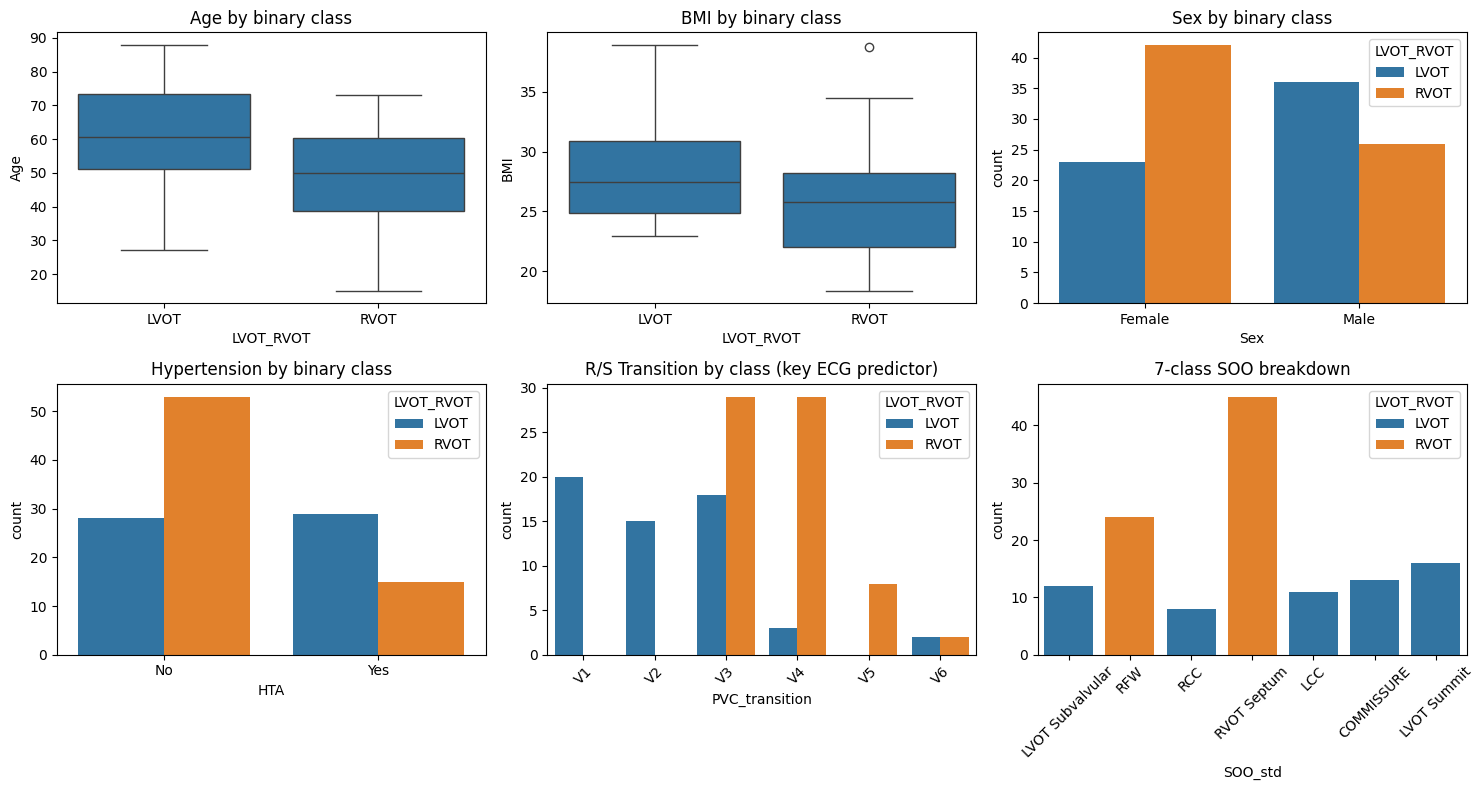

In [10]:
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Age by binary class
sns.boxplot(data=clinical_df_OT, x="LVOT_RVOT", y="Age", ax=axes[0,0])
axes[0,0].set_title("Age by binary class")

# BMI by binary class
sns.boxplot(data=clinical_df_OT, x="LVOT_RVOT", y="BMI", ax=axes[0,1])
axes[0,1].set_title("BMI by binary class")

# Sex by binary class
sns.countplot(data=clinical_df_OT, x="Sex", hue="LVOT_RVOT", ax=axes[0,2])
axes[0,2].set_title("Sex by binary class")

# HTA by binary class
sns.countplot(data=clinical_df_OT, x="HTA", hue="LVOT_RVOT", ax=axes[1,0])
axes[1,0].set_title("Hypertension by binary class")

# R/S transition: the KEY ECG predictor in the clinical literature
sns.countplot(data=clinical_df_OT, x="PVC_transition", hue="LVOT_RVOT", ax=axes[1,1],
              order=sorted(clinical_df_OT["PVC_transition"].dropna().unique()))
axes[1,1].set_title("R/S Transition by class (key ECG predictor)")
axes[1,1].tick_params(axis="x", rotation=45)

# 7-class breakdown
sns.countplot(data=clinical_df_OT, x="SOO_std", hue="LVOT_RVOT", ax=axes[1,2])
axes[1,2].set_title("7-class SOO breakdown")
axes[1,2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### 3.2. Sample ECG signals

Quick visual inspection of one LVOT and one RVOT patient (lead II). This helps
verify the data structure and confirms the PVC is in the last beat.


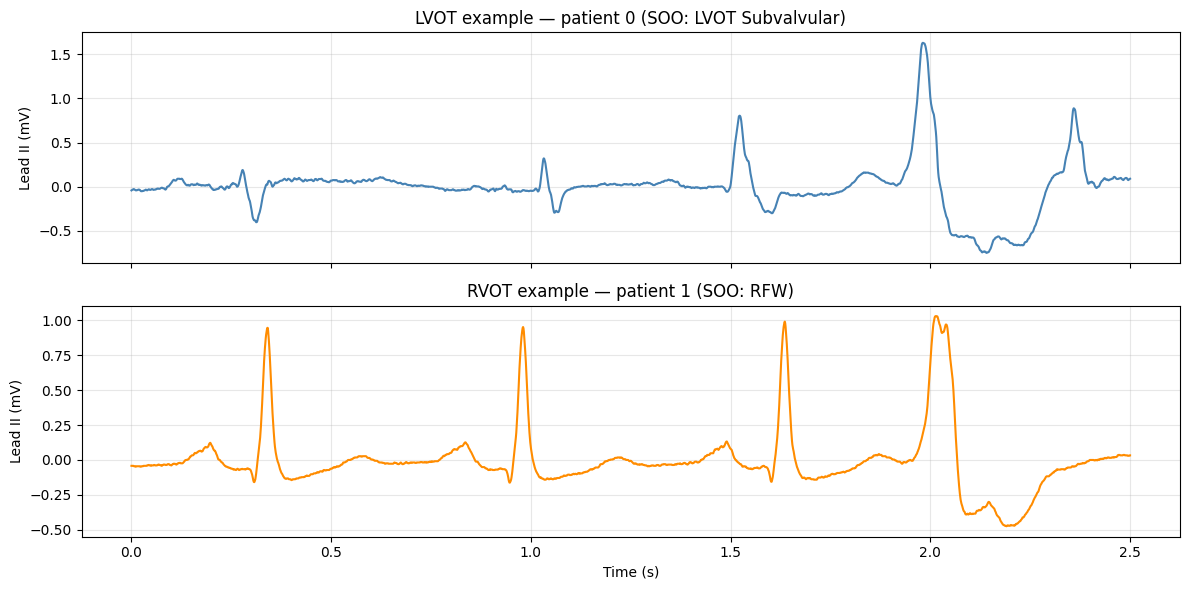

Note: the PVC is the last (4th) beat — wider QRS and abnormal morphology.


In [11]:
# Find one LVOT and one RVOT patient
lvot_local = clinical_df_OT[clinical_df_OT["LVOT_RVOT"]=="LVOT"].index[0]
rvot_local = clinical_df_OT[clinical_df_OT["LVOT_RVOT"]=="RVOT"].index[0]
lvot_orig = clinical_df_OT.iloc[lvot_local]["__orig_idx__"]
rvot_orig = clinical_df_OT.iloc[rvot_local]["__orig_idx__"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
t = np.linspace(0, 2.5, len(teknon["II"][lvot_orig]))

axes[0].plot(t, teknon["II"][lvot_orig], color="steelblue")
axes[0].set_title(f"LVOT example — patient {lvot_orig} (SOO: {clinical_df.iloc[lvot_orig]['SOO_std']})")
axes[0].set_ylabel("Lead II (mV)")
axes[0].grid(alpha=0.3)

axes[1].plot(t, teknon["II"][rvot_orig], color="darkorange")
axes[1].set_title(f"RVOT example — patient {rvot_orig} (SOO: {clinical_df.iloc[rvot_orig]['SOO_std']})")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Lead II (mV)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("Note: the PVC is the last (4th) beat — wider QRS and abnormal morphology.")


---
## 4. Preprocessing

This section transforms the raw data into the design matrices used by all
downstream models:

1. **Train/test split**: last 20% of OT-Teknon as fixed test set (project rule).
2. **QRS extraction from Teknon**: heuristic R-peak detection + window cropping
   (a workaround for the unavailable segmentation model from Jimenez-Perez et al.).
3. **Dataset combination**: train pool = Teknon train + DS-43 + DS-334 (~470 samples).
4. **Reshape + per-lead z-normalization** for the CNN.


### 4.1. Train/test split

In [12]:
# test = last 20% of Teknon. Applied AFTER OT filtering
# because non-OT patients are not part of the classification task.
n_train_pool = int(0.8 * len(clinical_df_OT))
teknon_train = clinical_df_OT.iloc[:n_train_pool].reset_index(drop=True)
teknon_test  = clinical_df_OT.iloc[n_train_pool:].reset_index(drop=True)

print(f"Teknon Train: {len(teknon_train)}  |  Teknon Test (fixed): {len(teknon_test)}")
print(f"\nTrain balance: {teknon_train['LVOT_RVOT'].value_counts().to_dict()}")
print(f"Test  balance: {teknon_test['LVOT_RVOT'].value_counts().to_dict()}")


Teknon Train: 103  |  Teknon Test (fixed): 26

Train balance: {'RVOT': 58, 'LVOT': 45}
Test  balance: {'LVOT': 15, 'RVOT': 11}


### 4.2. QRS extraction from Teknon

DS-43 and DS-334 already contain pre-segmented QRS complexes. Teknon contains
full 4-beat signals (2.5 s at 1000 Hz), so we must crop the PVC QRS to combine
the datasets.

**Method (heuristic R-peak detection):**
1. Stack the 12 leads into a `(2500, 12)` array.
2. Look at the **last 1 second** of the signal (where the PVC is — last beat).
3. Detect the R-peak as the point of maximum |amplitude| in **lead II**.
4. Crop a window of ~1024 samples around the R-peak.
5. Resample to 128 samples (same format as the .mat datasets).
6. L1-normalize per patient (same as the .mat loader).

In [13]:
from sklearn.preprocessing import normalize
from scipy.signal import resample

ECG_LEADS_TEKNON = ["I","II","III","AVR","AVL","AVF","V1","V2","V3","V4","V5","V6"]
FS_TEKNON = 1000   # original Teknon sampling rate

def extract_teknon_qrs(df, teknon, win_size=SAMPLE_SIZE):
    """Extract a 128-sample QRS window per Teknon patient via R-peak heuristic."""
    orig_idx = df["__orig_idx__"].values #original indexes
    N = len(orig_idx)
    X = np.zeros((N, 12 * win_size), dtype=np.float32) #matrix

    for i, idx in enumerate(orig_idx):
        # Stack 12 leads → shape (samples, 12)
        sigs = np.stack([np.asarray(teknon[lead][idx]).squeeze()
                        for lead in ECG_LEADS_TEKNON], axis=-1)
        # Look in last 1 s (the PVC is in the last beat)
        last_sec = sigs[-FS_TEKNON:, :] if sigs.shape[0] >= FS_TEKNON else sigs
        # R-peak heuristic: max |amplitude| in lead II --> Lead II chosen because clinically it's the reference for detecting the R peak
        lead_II_idx = ECG_LEADS_TEKNON.index("II")
        r_peak_local = np.argmax(np.abs(last_sec[:, lead_II_idx]))
        r_peak_global = sigs.shape[0] - last_sec.shape[0] + r_peak_local
        # Crop ~1024 samples around the peak --> we don't pass the limits of the signal
        lo = max(0, r_peak_global - win_size * 4)
        hi = min(sigs.shape[0], lo + win_size * 8)
        qrs_segment = sigs[lo:hi, :]
        # Resample to win_size
        if qrs_segment.shape[0] != win_size:
            qrs_segment = resample(qrs_segment, win_size, axis=0)
        # Flatten lead-by-lead (matches .mat format)
        for j in range(12):
            X[i, j*win_size:(j+1)*win_size] = qrs_segment[:, j]

    # L1-normalize per patient
    X = normalize(X, norm="l1")
    return X

# Apply to train and test
X_Teknon_train = extract_teknon_qrs(teknon_train, teknon)
X_Teknon_test  = extract_teknon_qrs(teknon_test, teknon)

# Encode labels (LVOT=0, RVOT=1) — matches .mat convention
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_Teknon_train = le.fit_transform(teknon_train["LVOT_RVOT"].values)
y_Teknon_test  = le.transform(teknon_test["LVOT_RVOT"].values)
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nTeknon train QRS: {X_Teknon_train.shape}")
print(f"Teknon test  QRS: {X_Teknon_test.shape}")
print(f"Matches .mat format? {X_Teknon_train.shape[1] == X_Clinic.shape[1]}")


Label mapping: {'LVOT': np.int64(0), 'RVOT': np.int64(1)}

Teknon train QRS: (103, 1536)
Teknon test  QRS: (26, 1536)
Matches .mat format? True


### 4.3. Combine datasets into a unified train pool

The combined train pool merges all three real-patient datasets:
- Teknon train: ~103 patients (with R-peak heuristic)
- DS-43 (Clínic): 43 patients
- DS-334 (Open-source): 333 patients

**Total: ~479 patients** 

**The test set remains untouched**: still only Teknon's last 20% (n=26).
The auxiliary datasets are train-only.


In [14]:
X_train_combined = np.concatenate([X_Teknon_train, X_Clinic, X_China], axis=0)
y_train_combined = np.concatenate([y_Teknon_train,
                                    y_Clinic.astype(int),
                                    y_China.astype(int)], axis=0)

# Track origin of each sample (for analysis only — not fed to the model)
origin_train = np.concatenate([
    np.full(len(X_Teknon_train), "Teknon"),
    np.full(len(X_Clinic), "DS-43"),
    np.full(len(X_China), "DS-334"),
])

print(f"Combined train pool: {X_train_combined.shape}")
print(f"Sources: {dict(zip(*np.unique(origin_train, return_counts=True)))}")
print(f"\nClass balance (combined train):")
print(f"  LVOT (0): {(y_train_combined==0).sum()}")
print(f"  RVOT (1): {(y_train_combined==1).sum()}")
print(f"\nTest set (Teknon only, untouched): {X_Teknon_test.shape}")


Combined train pool: (479, 1536)
Sources: {np.str_('DS-334'): np.int64(333), np.str_('DS-43'): np.int64(43), np.str_('Teknon'): np.int64(103)}

Class balance (combined train):
  LVOT (0): 148
  RVOT (1): 331

Test set (Teknon only, untouched): (26, 1536)


### 4.4. Reshape for CNN and standardize per lead

CNN expects `(N, 12 leads, 128 samples)` rather than flat `(N, 1536)`.
We also apply per-lead z-normalization (zero mean, unit std). Statistics are
computed from the **training set only** to avoid data leakage.


In [15]:
def reshape_for_cnn(X_flat, n_leads=12, win=SAMPLE_SIZE):
    """Convert flat (N, 12*128) to (N, 12, 128) for CNN input."""
    N = X_flat.shape[0]
    X_3d = np.zeros((N, n_leads, win), dtype=np.float32)
    for j in range(n_leads):
        X_3d[:, j, :] = X_flat[:, j*win:(j+1)*win]
    return X_3d

X_train_3d = reshape_for_cnn(X_train_combined)
X_test_3d  = reshape_for_cnn(X_Teknon_test)

# Per-lead z-normalization using TRAIN statistics only (no leakage)
lead_mean = X_train_3d.mean(axis=(0, 2), keepdims=True)
lead_std  = X_train_3d.std(axis=(0, 2), keepdims=True) + 1e-6
X_train_3d = (X_train_3d - lead_mean) / lead_std
X_test_3d  = (X_test_3d  - lead_mean) / lead_std   # use TRAIN stats

print(f"X_train_3d: {X_train_3d.shape}")
print(f"X_test_3d: {X_test_3d.shape}")
print(f"Per-lead mean (should be ~0): {X_train_3d.mean(axis=(0,2))[:4].round(3)}...")
print(f"Per-lead std (should be ~1): {X_train_3d.std(axis=(0,2))[:4].round(3)}...")


X_train_3d: (479, 12, 128)
X_test_3d: (26, 12, 128)
Per-lead mean (should be ~0): [-0. -0.  0.  0.]...
Per-lead std (should be ~1): [0.997 0.999 0.999 0.998]...


## 5. Baseline 1: Hybrid Score (Penela et al. 2023)

Clinical rule from the literature (slide 7 of the project introduction).
Combines clinical variables and R/S transition into a single score:

**Clinical points** (each contributes +1):
- Male sex
- Hypertension (HTA)
- Age > 50 years

**ECG points** (R/S precordial transition):
- V1 → +3, V2 → +2, V3 → +1, V4 → −2, V5 → −3, V6 → −4

**Decision rule:**
- Score ≥ 2 → LVOT
- Score ≤ 1 → RVOT

This is the **clinical baseline to beat**: if our ML models cannot outperform
this hand-crafted rule, they add no value.


In [16]:
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

def hybrid_score(row):
    """Compute the Penela 2023 Hybrid Score for one patient."""
    s = 0 #we initialize the score with 0
    # Clinical points
    if row.get("Sex") in ["M", "Male", 1, "1"]: #LVOT more frequent in male
        s += 1
    if row.get("HTA") in ["Yes", 1, "1", True]: #HTA dilates the left ventrical  
        s += 1
    age = row.get("Age", None) 
    if pd.notna(age) and float(age) > 50: #LVOT more common in elderly patients
        s += 1
    # ECG points (R/S transition)
    t = row.get("PVC_transition", None)
    if pd.isna(t):
        return s
    t_str = str(t).upper().replace("V", "").strip()
    try:
        t_num = float(t_str)
    except ValueError:
        return s
    
    #Penela 2023 
    if  t_num == 1: s += 3
    elif t_num == 2: s += 2
    elif t_num == 3: s += 1
    elif t_num == 4: s -= 2
    elif t_num == 5: s -= 3
    elif t_num == 6: s -= 4
    return s

# Apply to Teknon test set (the only one with clinical data)
scores_test = teknon_test.apply(hybrid_score, axis=1) #applies the function row per row
hybrid_pred = np.where(scores_test >= 2, "LVOT", "RVOT")
hybrid_true = teknon_test["LVOT_RVOT"].values

hybrid_acc = accuracy_score(hybrid_true, hybrid_pred)
hybrid_f1  = f1_score(hybrid_true, hybrid_pred, average="macro")
print(f"HYBRID SCORE (Penela 2023) on TEKNON TEST:")
print(f"Accuracy : {hybrid_acc:.3f}")
print(f"F1-macro : {hybrid_f1:.3f}")
print(f"\nClassification report:")
print(classification_report(hybrid_true, hybrid_pred, digits=3))


HYBRID SCORE (Penela 2023) on TEKNON TEST:
Accuracy : 0.654
F1-macro : 0.649

Classification report:
              precision    recall  f1-score   support

        LVOT      0.714     0.667     0.690        15
        RVOT      0.583     0.636     0.609        11

    accuracy                          0.654        26
   macro avg      0.649     0.652     0.649        26
weighted avg      0.659     0.654     0.655        26



## 6. Baseline 2: Random Forest with Handcrafted Features

Classical ML baseline using a combination of:
- **Clinical features** (Age, Sex, HTA, BMI, R/S transition, etc.).
- **Handcrafted ECG features** per lead (max, min, peak-to-peak, mean abs, plus
  derived metrics like R/S balance and inferior-lead positivity).

This setup mimics Model B of Bocanegra-Pérez et al. (2024). Trained only on
Teknon because DS-43 and DS-334 lack clinical metadata.

Preprocessing (imputation) is wrapped in a sklearn Pipeline so it is fitted
**only on training data within each CV fold** — preventing data leakage.


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

#Feature builders
def build_clinical_features(df):
    """Extract numeric clinical features. NaN are kept for the Pipeline imputer."""
    feats = pd.DataFrame(index=df.index) #we start with an empty dataset
    for c in ["Age", "Height", "Weight", "BMI", "CLINICAL_SCORE"]:
        feats[c] = pd.to_numeric(df[c], errors="coerce") #every non numerical value is NaN
    # Binary encoding
    sex_map = {"M": 1, "F": 0, "Male": 1, "Female": 0, 1: 1, 0: 0}
    feats["Sex_M"] = df["Sex"].map(sex_map)
    for c in ["HTA", "DM", "DLP", "Smoker", "COPD", "Sleep_apnea"]:
        feats[c] = df[c].map({"Yes": 1, "No": 0, 1: 1, 0: 0})
    # PVC transition: ordinal (V1=1, ..., V6=6)
    def enc_t(v):
        if pd.isna(v): return np.nan
        s = str(v).upper().replace("V", "").strip()
        try: return float(s)
        except: return np.nan
    feats["PVC_transition"] = df["PVC_transition"].apply(enc_t)
    return feats

def build_handcrafted_ecg_features(X_flat, win=SAMPLE_SIZE, n_leads=12):
    """Per-lead amplitude statistics + clinical-style derived features."""
    X3 = reshape_for_cnn(X_flat, n_leads=n_leads, win=win)
    LEADS = ["I","II","III","AVR","AVL","AVF","V1","V2","V3","V4","V5","V6"]
    feats = {}
    for j, lead in enumerate(LEADS):
        sig = X3[:, j, :]
        feats[f"{lead}_max"] = sig.max(axis=1) #Maximum positive amplitude (R peak in most leads)
        feats[f"{lead}_min"] = sig.min(axis=1) #Maximum negative ampltiude (S or Q depending on the lead)
        feats[f"{lead}_ptp"] = sig.max(axis=1) - sig.min(axis=1) #Total ampltiude of QRS
        feats[f"{lead}_meanabs"] = np.abs(sig).mean(axis=1) #Mean
    # R/S balance per precordial lead
    for lead in ["V1","V2","V3","V4","V5","V6"]:
        feats[f"{lead}_RS_balance"] = feats[f"{lead}_max"] + feats[f"{lead}_min"]
    # Inferior-lead positivity (II + III + AVF) --> It codifies directly the R/S transition 
    feats["inferior_pos"] = feats["II_max"] + feats["III_max"] + feats["AVF_max"] #It confirms the patient is OT-VA  (not discriminate LVOT and RVOT directly)
    return pd.DataFrame(feats)

# Build design matrices 
X_clin_train = build_clinical_features(teknon_train).reset_index(drop=True)
X_clin_test = build_clinical_features(teknon_test).reset_index(drop=True)
X_ecg_train = build_handcrafted_ecg_features(X_Teknon_train).reset_index(drop=True)
X_ecg_test = build_handcrafted_ecg_features(X_Teknon_test).reset_index(drop=True)

#we concatenate 13 clinical features and 60 ECG features (73 total features)
X_RF_train = pd.concat([X_clin_train, X_ecg_train], axis=1)
X_RF_test = pd.concat([X_clin_test,  X_ecg_test],  axis=1)
y_RF_train = y_Teknon_train
y_RF_test = y_Teknon_test

print(f"RF features: {X_RF_train.shape[1]}  "
      f"(clinical: {X_clin_train.shape[1]}, ECG: {X_ecg_train.shape[1]})")
print(f"RF train: {X_RF_train.shape}  |  RF test: {X_RF_test.shape}")


RF features: 68  (clinical: 13, ECG: 55)
RF train: (103, 68)  |  RF test: (26, 68)


In [18]:
# Random Forest with Pipeline (median imputation) --> we want to avoid data leakage
pipe_rf = Pipeline([
    ("imp", SimpleImputer(strategy="median")), #it fills the NaNs with the median
    ("clf", RandomForestClassifier(n_estimators=300, #300 decision trees 
                                    class_weight="balanced", #it compensates the imbalance 60/69
                                    random_state=42, #seed
                                    n_jobs=-1)),
])
pipe_rf.fit(X_RF_train, y_RF_train)

# Evaluate
rf_pred  = pipe_rf.predict(X_RF_test)
rf_proba = pipe_rf.predict_proba(X_RF_test)[:, 1]
rf_acc = accuracy_score(y_RF_test, rf_pred)
rf_f1  = f1_score(y_RF_test, rf_pred, average="macro")

print(f"RANDOM FOREST (Teknon, clinical + handcrafted ECG features):")
print(f"Test accuracy : {rf_acc:.3f}")
print(f"Test F1-macro : {rf_f1:.3f}")
print(f"\nClassification report:")
print(classification_report(y_RF_test, rf_pred, target_names=le.classes_, digits=3))


RANDOM FOREST (Teknon, clinical + handcrafted ECG features):
Test accuracy : 0.808
Test F1-macro : 0.807

Classification report:
              precision    recall  f1-score   support

        LVOT      0.917     0.733     0.815        15
        RVOT      0.714     0.909     0.800        11

    accuracy                          0.808        26
   macro avg      0.815     0.821     0.807        26
weighted avg      0.831     0.808     0.809        26



## 7. Main Model: CNN (Saglietto 2024-inspired)

End-to-end deep learning on raw 12-lead ECG. The architecture and training
model are inspired by **Saglietto et al. 2024**, with these design choices:

- **Lightweight**: ~11k trainable parameters — appropriate for small datasets.
- **Two-stage CNN**: per-lead temporal convolutions (grouped conv, leads
  processed independently) followed by inter-lead fusion (1×1 conv).
- **Multi-source training**: combined Teknon + DS-43 + DS-334 (~479 patients).
- **Data augmentation**: 5 transforms (Gaussian noise,
  amplitude scaling, time shift, time scale, lead dropout) applied per epoch.


### 7.1. PyTorch dataset with augmentation

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print(f"PyTorch version: {torch.__version__}")

class ECGDataset(Dataset):
    """ECG dataset with 5 random augmentations (applied only when augment=True)."""

    def __init__(self, X, y, augment=False):
        self.X = torch.from_numpy(X).float() #numpy to torch tensor
        self.y = torch.from_numpy(y).long() #labels in int64
        self.augment = augment #ONLY ACTIVATED AT TRAIN, NEVER IN VALIDATION AND TEST

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            # AUGMENTATION 1: Gaussian noise (simulates electrode noise)
            noise_std = np.random.uniform(0.01, 0.05)
            x = x + torch.randn_like(x) * noise_std
            # AUGMENTATION 2: Amplitude scaling (simulates inter-equipment differences)
            amp = np.random.uniform(0.8, 1.2) #multiplies by 0.8-1.2
            x = x * amp
            # AUGMENATION 3: Time shifting (simulates QRS misalignment)
            shift = np.random.randint(-5, 6) #displaces temporally the signal +- 5 samples
            if shift != 0:
                x = torch.roll(x, shifts=shift, dims=-1) #displaces circularly
            # AUGMENATION 4: Time scaling (stretch/compress +-10%) — heart rate variability
            if np.random.rand() < 0.5: #only applied with probability 50%
                factor = np.random.uniform(0.9, 1.1) #generates a factor between 0.9-1.1
                new_len = max(64, int(x.shape[-1] * factor))
                x_resamp = F.interpolate(x.unsqueeze(0), size=new_len, mode="linear",
                                          align_corners=False).squeeze(0)
                if new_len > x.shape[-1]:
                    start = (new_len - x.shape[-1]) // 2
                    x = x_resamp[:, start:start + x.shape[-1]]
                else:
                    pad_left = (x.shape[-1] - new_len) // 2
                    pad_right = x.shape[-1] - new_len - pad_left
                    x = F.pad(x_resamp, (pad_left, pad_right), mode="constant", value=0)
            # AUGMENATION 5: Lead dropout (simulates bad electrode contact)
            if np.random.rand() < 0.1: #with probability of 10% it puts a random lead to zeros
                lead_to_drop = np.random.randint(12)
                x[lead_to_drop] = 0
        return x, self.y[idx]


PyTorch version: 2.4.1+cpu


### 7.2. CNN architecture


In [20]:
class ECG_CNN(nn.Module):
    """Lightweight 1D CNN for ECG classification (Saglietto 2024-inspired)."""

    def __init__(self, n_leads=12, n_classes=2):
        super().__init__()

        def make_block(in_ch, out_ch, k, dilation=1):
            """Conv + BN + LeakyReLU + MaxPool, grouped by 12 (per-lead independent)."""
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=k, padding=k//2 * dilation,
                          dilation=dilation, groups=12), #1D convolution (learns patterns in time)
                nn.BatchNorm1d(out_ch), #Batch Normalization --> accelerate the training
                nn.LeakyReLU(0.1), #non-Lineal activation
                nn.MaxPool1d(2), #reduces the temporal dimension to the half 
            )

        # Stage 1: per-lead temporal feature extraction --> process each lead independently throughout time
        self.block1 = make_block(12, 24, k=5)   # 128 → 64 (we start with big kernels)
        self.block2 = make_block(24, 48, k=5)   #  64 → 32
        self.block3 = make_block(48, 96, k=3)   #  32 → 16
        self.block4 = make_block(96, 96, k=3)   #  16 →  8 (we end with smaller kernels)
        self.dropout = nn.Dropout(0.3) #Dropout of 30% during training (avoid overfitting, puts randomly the 30% of the neurons to 0)

        # Stage 2: inter-lead fusion: it mixes the information between leads at the end
        self.fuse = nn.Sequential(
            nn.Conv1d(96, 64, kernel_size=1),   # 1×1 conv mixes leads
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
        )

        # Stage 3: classifier
        self.gap = nn.AdaptiveAvgPool1d(1) #Global Average Pooling
        self.classifier = nn.Sequential(
            nn.Flatten(),  #(B.64,1) --> (B,64)
            nn.Dropout(0.3), #30% Dropout again
            nn.Linear(64, n_classes), #64 --> 2 logits (RVOT,LVOT)
        )

    def forward(self, x):
        x = self.block1(x); x = self.block2(x); x = self.block3(x); x = self.block4(x)
        x = self.dropout(x); x = self.fuse(x); x = self.gap(x)
        return self.classifier(x)

# Sanity check
model = ECG_CNN()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {n_params:,}")
dummy = torch.randn(4, 12, SAMPLE_SIZE)
print(f"Dummy output shape: {model(dummy).shape}  (should be [4, 2])")


Total trainable parameters: 11,314
Dummy output shape: torch.Size([4, 2])  (should be [4, 2])


### 7.3. Training loop with early stopping

Standard supervised training:
- **Optimizer**: Adam with weight decay 1e-4 (L2 regularization).
- **Loss**: Cross-entropy with `class_weight="balanced"` (compensates imbalance).
- **Scheduler**: Cosine annealing LR (1e-3 → 0 over 80 epochs).
- **Early stopping**: patience=15 epochs on validation F1-macro.


In [21]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.utils.class_weight import compute_class_weight

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Training on: {DEVICE}")

def train_one_fold(X_tr, y_tr, X_val, y_val, n_epochs=80, batch_size=32,
                   lr=1e-3, patience=15, verbose=False):
    """Train one CV fold. Returns (best_val_f1, trained_model)."""
    train_ds = ECGDataset(X_tr, y_tr, augment=True) #we only augmentate the train set
    val_ds = ECGDataset(X_val, y_val, augment=False) #NEVER THE VALIDATION SET
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True) #shuffle=True to avoid overfitting so that the model doesn't learn the orden of the dataset (not overfitting)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = ECG_CNN().to(DEVICE)
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    cw_tensor = torch.tensor(cw, dtype=torch.float32, device=DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw_tensor)
    #making a mistake in LVOT (minoritary class) penalises more than mistaking in a RVOT
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    best_f1, best_state, patience_counter = 0.0, None, 0
    for epoch in range(n_epochs):
        # Training phase
        model.train() 
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        scheduler.step()
        # Validation phase
        model.eval()
        all_pred, all_true = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                pred = model(xb.to(DEVICE)).argmax(1).cpu().numpy()
                all_pred.extend(pred); all_true.extend(yb.numpy())
        f1 = f1_score(all_true, all_pred, average="macro")
        # Track best model + early stopping
        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience: #early stopping if no improvement in 15 epochs
                if verbose: print(f"  Early stopping at epoch {epoch+1}")
                break
        if verbose and (epoch+1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}  val F1 = {f1:.3f}  (best {best_f1:.3f})")
    model.load_state_dict(best_state)
    return best_f1, model


Training on: cpu


### 7.4. 5-fold cross-validation

In [22]:
torch.manual_seed(42); np.random.seed(42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_f1s = []
print("Running 5-fold CV on combined train pool (~479 patients)...")
for k, (tr_idx, val_idx) in enumerate(skf.split(X_train_3d, y_train_combined)):
    print(f"\nFold {k+1}/5")
    f1, _ = train_one_fold(
        X_train_3d[tr_idx], y_train_combined[tr_idx],
        X_train_3d[val_idx], y_train_combined[val_idx],
        verbose=True,
    )
    print(f"  → Fold {k+1} best val F1-macro: {f1:.3f}")
    fold_f1s.append(f1)

cv_mean = np.mean(fold_f1s)
cv_std  = np.std(fold_f1s)
print(f"\nCV F1-macro: {cv_mean:.3f} ± {cv_std:.3f}")
print(f"Per-fold: {[round(f, 3) for f in fold_f1s]}")


Running 5-fold CV on combined train pool (~479 patients)...

Fold 1/5
  Epoch  10  val F1 = 0.733  (best 0.742)
  Epoch  20  val F1 = 0.762  (best 0.779)
  Epoch  30  val F1 = 0.776  (best 0.812)
  Epoch  40  val F1 = 0.782  (best 0.812)
  Early stopping at epoch 41
  → Fold 1 best val F1-macro: 0.812

Fold 2/5
  Epoch  10  val F1 = 0.868  (best 0.868)
  Epoch  20  val F1 = 0.833  (best 0.868)
  Early stopping at epoch 25
  → Fold 2 best val F1-macro: 0.868

Fold 3/5
  Epoch  10  val F1 = 0.874  (best 0.874)
  Epoch  20  val F1 = 0.886  (best 0.886)
  Epoch  30  val F1 = 0.897  (best 0.908)
  Epoch  40  val F1 = 0.897  (best 0.908)
  Early stopping at epoch 43
  → Fold 3 best val F1-macro: 0.908

Fold 4/5
  Epoch  10  val F1 = 0.876  (best 0.876)
  Epoch  20  val F1 = 0.865  (best 0.879)
  Epoch  30  val F1 = 0.852  (best 0.888)
  Epoch  40  val F1 = 0.841  (best 0.888)
  Early stopping at epoch 41
  → Fold 4 best val F1-macro: 0.888

Fold 5/5
  Epoch  10  val F1 = 0.856  (best 0.856)


### 7.5. Train final model + evaluate on test

Final model trained on the full combined train pool. We hold out 15% as a
monitoring set for early stopping (still part of the train pool, not the
real test set).


In [23]:
torch.manual_seed(42); np.random.seed(42)

# Split off 15% as monitoring set for early stopping
X_tr_final, X_mon, y_tr_final, y_mon = train_test_split(
    X_train_3d, y_train_combined,
    test_size=0.15, stratify=y_train_combined, random_state=42
) #stratification to mantain the balance in classes
print(f"Final train: {len(y_tr_final)}  |  Monitor: {len(y_mon)}")

_, final_model = train_one_fold(
    X_tr_final, y_tr_final, X_mon, y_mon,
    n_epochs=80, verbose=True
)


Final train: 407  |  Monitor: 72
  Epoch  10  val F1 = 0.776  (best 0.776)
  Epoch  20  val F1 = 0.724  (best 0.776)
  Epoch  30  val F1 = 0.737  (best 0.789)
  Early stopping at epoch 38


In [24]:
# Final evaluation on the held-out Teknon test set (ONCE) 
final_model.eval()
test_ds = ECGDataset(X_test_3d, y_Teknon_test, augment=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

all_pred, all_true, cnn_proba_list = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = final_model(xb.to(DEVICE))
        proba = F.softmax(logits, dim=1)[:, 1].cpu().numpy()   # P(RVOT)
        pred = logits.argmax(1).cpu().numpy()
        all_pred.extend(pred); all_true.extend(yb.numpy()); cnn_proba_list.extend(proba)

y_pred = np.array(all_pred); y_true = np.array(all_true)
cnn_proba = np.array(cnn_proba_list)

test_acc = accuracy_score(y_true, y_pred)
test_f1  = f1_score(y_true, y_pred, average="macro")

print(f"CNN FINAL TEST RESULTS")
print(f"Test accuracy : {test_acc:.3f}")
print(f"Test F1-macro : {test_f1:.3f}")
print(f"\nClassification report:")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=3))


CNN FINAL TEST RESULTS
Test accuracy : 0.846
Test F1-macro : 0.842

Classification report:
              precision    recall  f1-score   support

        LVOT      0.867     0.867     0.867        15
        RVOT      0.818     0.818     0.818        11

    accuracy                          0.846        26
   macro avg      0.842     0.842     0.842        26
weighted avg      0.846     0.846     0.846        26



## 8. Late-Fusion Ensemble (RF + CNN)

Combine the two ML models by averaging their predicted probabilities:

$$P_\text{ensemble}(\text{RVOT}) = 0.5 \cdot P_\text{RF}(\text{RVOT}) + 0.5 \cdot P_\text{CNN}(\text{RVOT})$$

The motivation is that RF and CNN capture different views of the data:
- **RF**: uses clinical features (Age, Sex, HTA) + handcrafted ECG features.
- **CNN**: uses raw ECG signals from multiple datasets.

We choose late fusion because we let each model predict independently and then combine the final probabilities (instead of Early Fusion, combining all features before classifying)

If both views are complementary, the ensemble should beat both individual models.


In [25]:
# Both models predicted on the same 26 test patients in the same order
assert len(rf_proba) == len(cnn_proba) == len(y_Teknon_test)

# Late fusion: average probabilities, threshold 0.5 (both equally important)
ens_proba = 0.5 * rf_proba + 0.5 * cnn_proba
ens_pred = (ens_proba >= 0.5).astype(int)

ens_acc = accuracy_score(y_Teknon_test, ens_pred)
ens_f1 = f1_score(y_Teknon_test, ens_pred, average="macro")

print(f"ENSEMBLE (RF + CNN, 50/50)")
print(f"Test accuracy : {ens_acc:.3f}")
print(f"Test F1-macro : {ens_f1:.3f}")
print(f"\nClassification report:")
print(classification_report(y_Teknon_test, ens_pred, target_names=le.classes_, digits=3))


ENSEMBLE (RF + CNN, 50/50)
Test accuracy : 0.808
Test F1-macro : 0.805

Classification report:
              precision    recall  f1-score   support

        LVOT      0.857     0.800     0.828        15
        RVOT      0.750     0.818     0.783        11

    accuracy                          0.808        26
   macro avg      0.804     0.809     0.805        26
weighted avg      0.812     0.808     0.809        26



## 9. Final Comparison and Interpretability

This section produces:
1. Summary table of all 4 models.
2. Side-by-side confusion matrices.
3. CNN saliency maps (per-patient interpretability).
4. Lead importance ranking (averaged across correctly classified test patients).


### 9.1. Summary table

In [26]:
cm_cnn = confusion_matrix(y_true, y_pred)
print("="*70)
print("  TASK 1 — FINAL COMPARISON (test = last 20% Teknon, n=26)")
print("="*70)
print(f"{'Model':40s} {'Accuracy':>10s} {'F1-macro':>10s}")
print(f"{'-'*40} {'-'*10} {'-'*10}")
print(f"{'Hybrid Score (Penela 2023, clinical)':40s} {hybrid_acc:>10.3f} {hybrid_f1:>10.3f}")
print(f"{'Random Forest (Teknon, clinical+ECG)':40s} {rf_acc:>10.3f} {rf_f1:>10.3f}")
print(f"{'CNN (Combined datasets, ECG only)':40s} {test_acc:>10.3f} {test_f1:>10.3f}")
print(f"{'Ensemble RF + CNN (50/50)':40s} {ens_acc:>10.3f} {ens_f1:>10.3f}")
print("="*70)


  TASK 1 — FINAL COMPARISON (test = last 20% Teknon, n=26)
Model                                      Accuracy   F1-macro
---------------------------------------- ---------- ----------
Hybrid Score (Penela 2023, clinical)          0.654      0.649
Random Forest (Teknon, clinical+ECG)          0.808      0.807
CNN (Combined datasets, ECG only)             0.846      0.842
Ensemble RF + CNN (50/50)                     0.808      0.805


### 9.2. Confusion matrices (all 4 models)

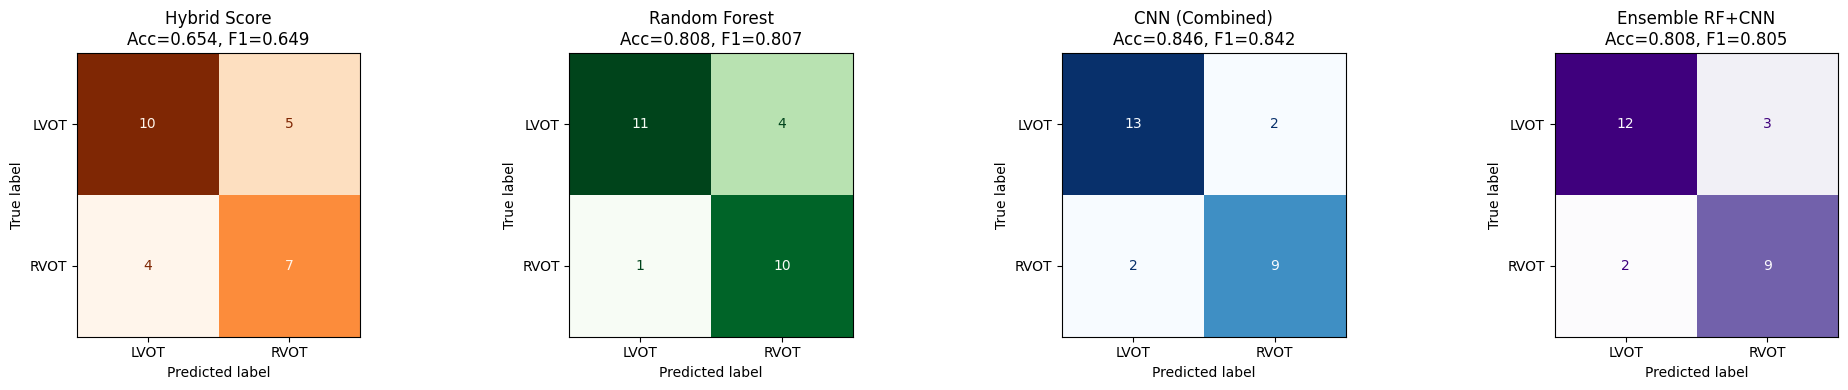

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Hybrid Score (uses string labels)
cm_h = confusion_matrix(hybrid_true, hybrid_pred, labels=["LVOT", "RVOT"])
ConfusionMatrixDisplay(cm_h, display_labels=["LVOT", "RVOT"]).plot(
    cmap="Oranges", ax=axes[0], colorbar=False)
axes[0].set_title(f"Hybrid Score\nAcc={hybrid_acc:.3f}, F1={hybrid_f1:.3f}")

# RF
cm_rf = confusion_matrix(y_RF_test, rf_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=list(le.classes_)).plot(
    cmap="Greens", ax=axes[1], colorbar=False)
axes[1].set_title(f"Random Forest\nAcc={rf_acc:.3f}, F1={rf_f1:.3f}")

# CNN
ConfusionMatrixDisplay(cm_cnn, display_labels=list(le.classes_)).plot(
    cmap="Blues", ax=axes[2], colorbar=False)
axes[2].set_title(f"CNN (Combined)\nAcc={test_acc:.3f}, F1={test_f1:.3f}")

# Ensemble
cm_ens = confusion_matrix(y_Teknon_test, ens_pred)
ConfusionMatrixDisplay(cm_ens, display_labels=list(le.classes_)).plot(
    cmap="Purples", ax=axes[3], colorbar=False)
axes[3].set_title(f"Ensemble RF+CNN\nAcc={ens_acc:.3f}, F1={ens_f1:.3f}")

plt.tight_layout()
plt.show()


### 9.3. Saliency maps — CNN interpretability

For each test sample, we compute `|∂(output_class)/∂(input)|`. High values
indicate parts of the ECG that strongly influenced the prediction. We visualize
two correctly classified examples (one LVOT, one RVOT) as a red intensity
heatmap behind each lead. Source: Simonyan, K., Vedaldi, A., Zisserman, A. (2014) 


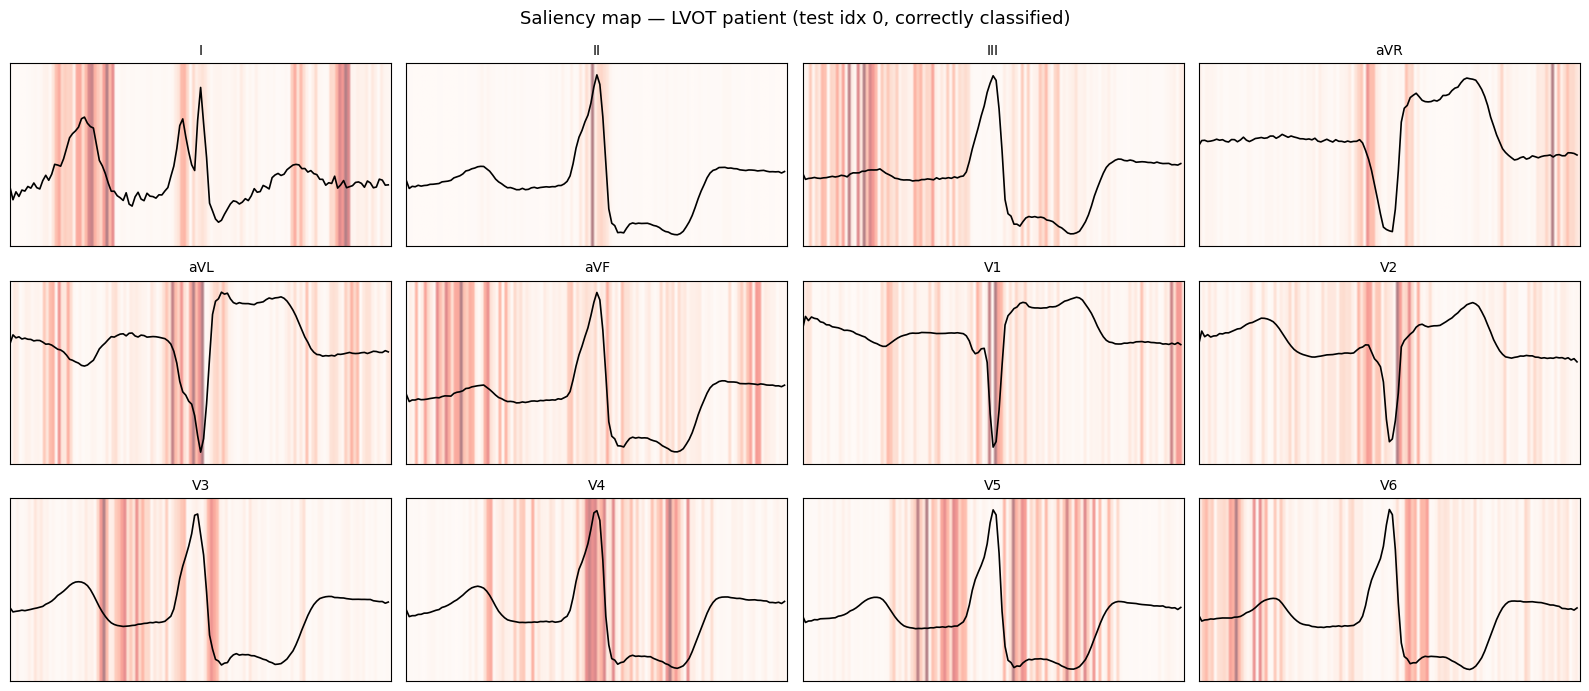

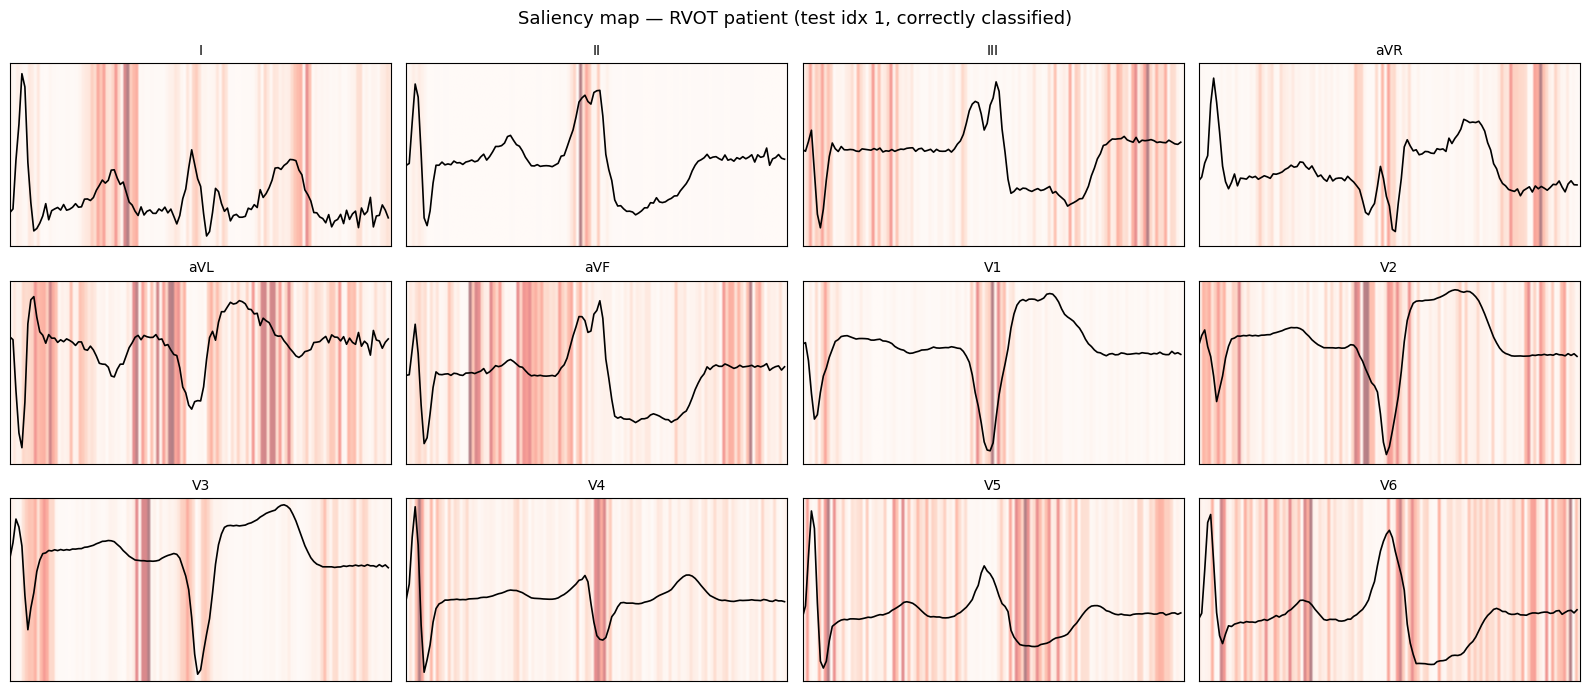

In [28]:
final_model.eval()

def compute_saliency(model, x, target_class):
    """Return |∂(output[target_class])/∂(input)|, shape (12, 128)."""
    x = x.clone().detach().requires_grad_(True)
    output = model(x)
    score = output[0, target_class]
    score.backward()
    return x.grad.abs()[0].cpu().numpy()

# Predict test set in one pass (already done above as y_pred)
preds_test = y_pred
correct_mask = (preds_test == y_Teknon_test)
test_tensor = torch.from_numpy(X_test_3d).float().to(DEVICE)

# Pick first correctly classified LVOT and RVOT
lvot_idx = np.where((y_Teknon_test == 0) & correct_mask)[0][0]
rvot_idx = np.where((y_Teknon_test == 1) & correct_mask)[0][0]

sal_lvot = compute_saliency(final_model, test_tensor[lvot_idx:lvot_idx+1], target_class=0)
sal_rvot = compute_saliency(final_model, test_tensor[rvot_idx:rvot_idx+1], target_class=1)

LEAD_NAMES = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

def plot_saliency(signal, saliency, title):
    fig, axes = plt.subplots(3, 4, figsize=(16, 7), sharex=True)
    for j, ax in enumerate(axes.flat):
        sig = signal[j]
        sal = saliency[j]
        sal_norm = (sal - sal.min()) / (sal.max() - sal.min() + 1e-9)
        ax.imshow(sal_norm[np.newaxis, :], aspect="auto",
                  extent=[0, len(sig), sig.min()-0.5, sig.max()+0.5],
                  cmap="Reds", alpha=0.5)
        ax.plot(sig, color="black", linewidth=1.2)
        ax.set_title(LEAD_NAMES[j], fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_saliency(X_test_3d[lvot_idx], sal_lvot,
              f"Saliency map — LVOT patient (test idx {lvot_idx}, correctly classified)")
plot_saliency(X_test_3d[rvot_idx], sal_rvot,
              f"Saliency map — RVOT patient (test idx {rvot_idx}, correctly classified)")


### 9.4. Lead importance (averaged across test set)

Mean saliency per lead across all correctly classified test patients. This
ranks how much each lead contributes to the CNN's decision. We expect V3 to
rank highest, since the R/S transition at V3 is the single most predictive
ECG feature in the clinical literature (Penela 2023; Bocanegra-Pérez 2024).


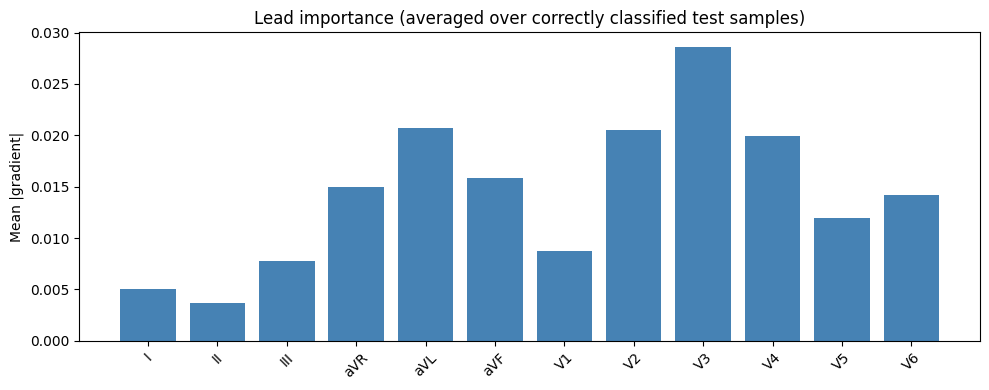


══ Lead importance ranking ══
   1. V3   : 0.0286
   2. aVL  : 0.0207
   3. V2   : 0.0205
   4. V4   : 0.0199
   5. aVF  : 0.0159
   6. aVR  : 0.0150
   7. V6   : 0.0142
   8. V5   : 0.0119
   9. V1   : 0.0088
  10. III  : 0.0077
  11. I    : 0.0050
  12. II   : 0.0037


In [29]:
all_sal = []
for i in range(len(X_test_3d)):
    if correct_mask[i]:
        s = compute_saliency(final_model, test_tensor[i:i+1],
                              target_class=int(y_Teknon_test[i]))
        all_sal.append(s.mean(axis=1))   # mean over time for each lead
mean_sal_per_lead = np.array(all_sal).mean(axis=0)

# Bar plot
plt.figure(figsize=(10, 4))
plt.bar(LEAD_NAMES, mean_sal_per_lead, color="steelblue")
plt.ylabel("Mean |gradient|")
plt.title("Lead importance (averaged over correctly classified test samples)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Ranked output
print("\n══ Lead importance ranking ══")
ranking = sorted(zip(LEAD_NAMES, mean_sal_per_lead), key=lambda x: -x[1])
for rank, (name, val) in enumerate(ranking, 1):
    print(f"  {rank:2d}. {name:5s}: {val:.4f}")


### 9.5. Failure Analysis

The misclassified patients have transition in V3 (ambigous) or in other cases?

In [30]:
#Predictions of the final CNN model in test
test_tensor = torch.from_numpy(X_test_3d).float().to(DEVICE)
with torch.no_grad():
    preds_test = final_model(test_tensor).argmax(1).cpu().numpy()

#error masks
error_mask = (preds_test != y_Teknon_test)
correct_mask = ~error_mask

print(f"Total test patients: {len(y_Teknon_test)}")
print(f"Correct: {correct_mask.sum()}  |  Errors: {error_mask.sum()}")

error_indices = np.where(error_mask)[0]

print("\nMISCLASSIFIED PATIENTS")
print(f"{'Idx':>4} {'True':>6} {'Pred':>6} {'PVC_transition':>15} {'SOO_std':>20}")

for i in error_indices:
    true_label = le.classes_[y_Teknon_test[i]]
    pred_label = le.classes_[preds_test[i]]
    pvc_trans  = teknon_test.iloc[i]["PVC_transition"]
    soo        = teknon_test.iloc[i]["SOO_std"]
    print(f"{i:>4} {true_label:>6} {pred_label:>6} {str(pvc_trans):>15} {str(soo):>20}")

# In which transitions are the mistakes?
print("\nPVC TRANSITION OF MISCLASSIFIED PATIENTS")
error_transitions = teknon_test.iloc[error_indices]["PVC_transition"].values
print(f"Transitions: {error_transitions}")

print("\nPVC TRANSITION: ERRORS vs CORRECT")
print("Errors:")
print(teknon_test.iloc[error_indices]["PVC_transition"].value_counts())
print("\nCorrect:")
print(teknon_test.iloc[np.where(correct_mask)[0]]["PVC_transition"].value_counts())

Total test patients: 26
Correct: 22  |  Errors: 4

MISCLASSIFIED PATIENTS
 Idx   True   Pred  PVC_transition              SOO_std
   5   LVOT   RVOT              V3                  LCC
   6   RVOT   LVOT              V4          RVOT Septum
   8   LVOT   RVOT              V3     LVOT Subvalvular
  17   RVOT   LVOT              V3          RVOT Septum

PVC TRANSITION OF MISCLASSIFIED PATIENTS
Transitions: <ArrowStringArray>
['V3', 'V4', 'V3', 'V3']
Length: 4, dtype: str

PVC TRANSITION: ERRORS vs CORRECT
Errors:
PVC_transition
V3    3
V4    1
Name: count, dtype: int64

Correct:
PVC_transition
V3    6
V1    5
V4    5
V5    2
V2    2
V6    1
Name: count, dtype: int64
